In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import sklearn.datasets

In [2]:
x, y = sklearn.datasets.make_moons(200, noise=0.20)

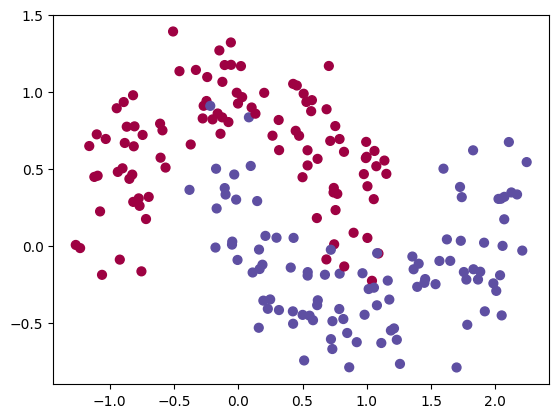

In [5]:
plt.scatter(x[:,0], x[:,1], s=40, c=y, cmap=plt.cm.Spectral)
plt.show()

In [6]:
x = torch.FloatTensor(x)
y = torch.LongTensor(y)

In [12]:
class FeedForward(nn.Module):
    def __init__(self, input_neurons, hidden_neurons, output_neurons):
        super(FeedForward, self).__init__()
        self.hidden = nn.Linear(input_neurons, hidden_neurons)
        self.out = nn.Linear(hidden_neurons, output_neurons)
    def forward(self, x):
        x = self.hidden(x)
        x = F.relu(x)
        x = self.out(x)
        return x

In [13]:
network = FeedForward(input_neurons=2, hidden_neurons=50, output_neurons=2)
optimizer = torch.optim.SGD(network.parameters(), lr=0.02)
loss_function = nn.CrossEntropyLoss()

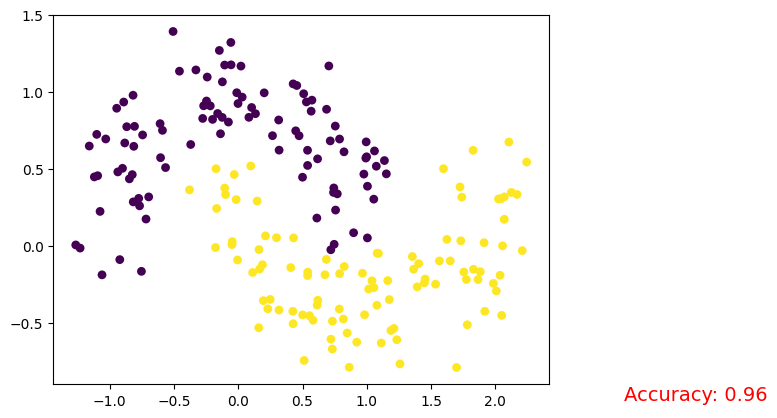

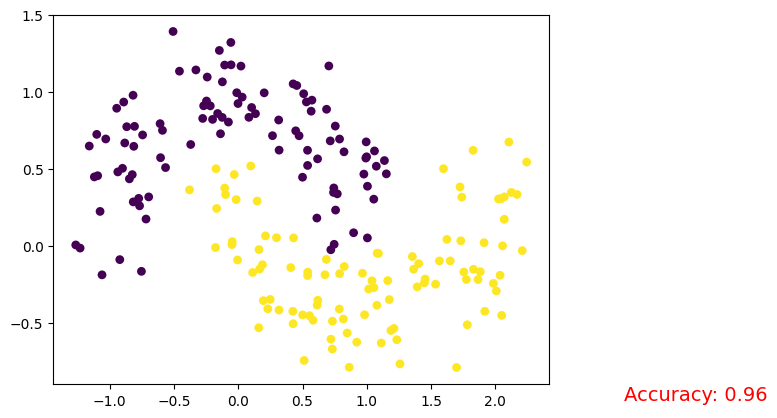

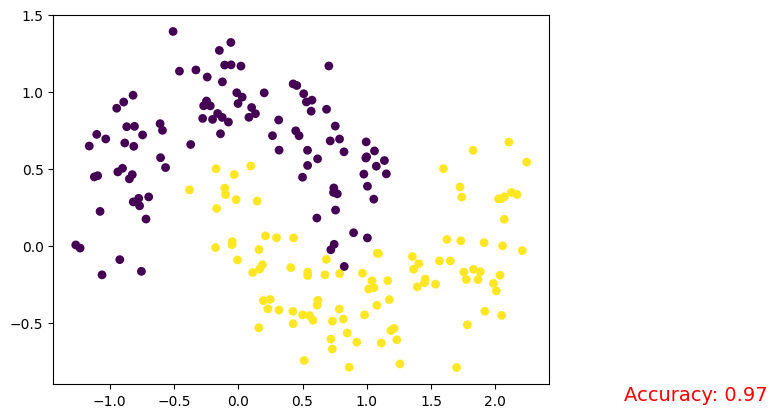

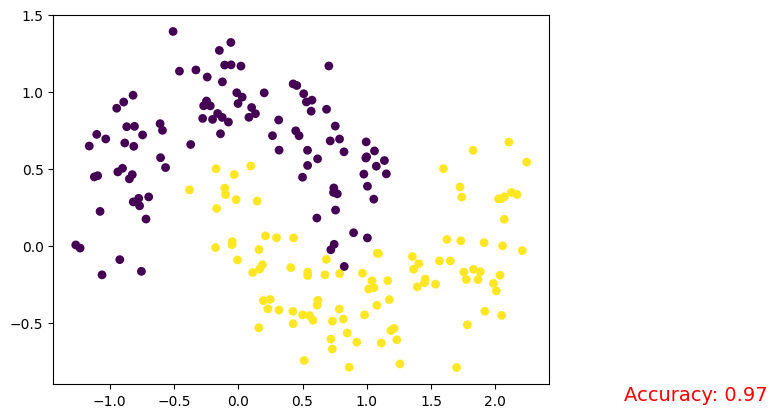

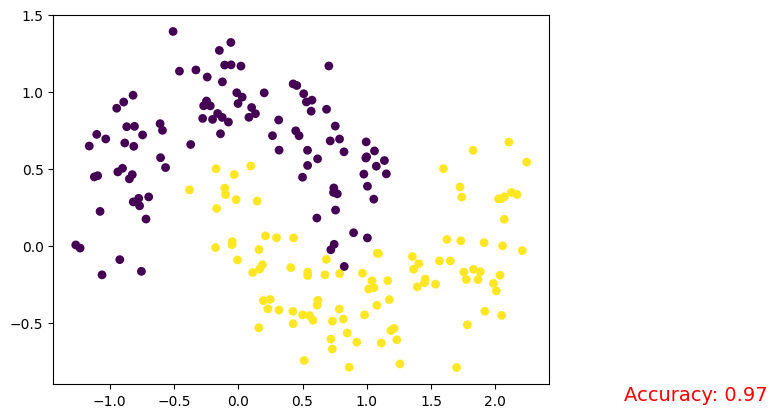

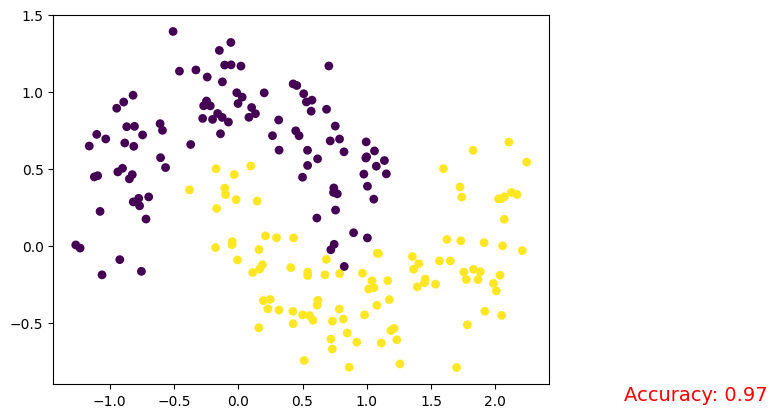

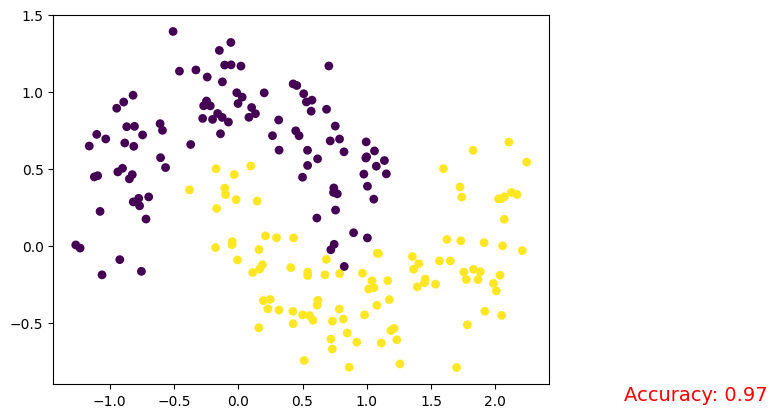

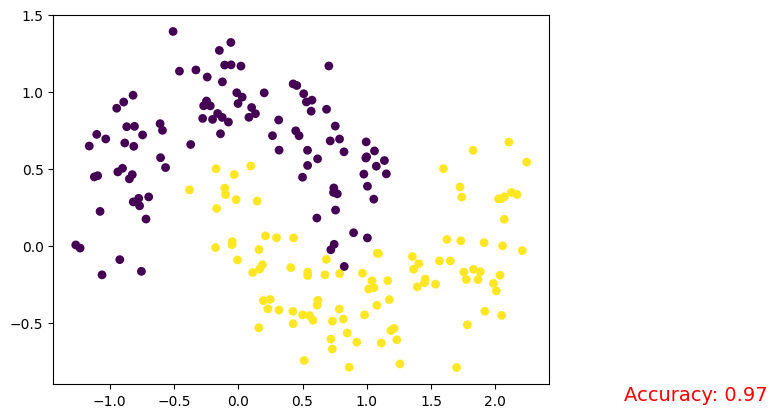

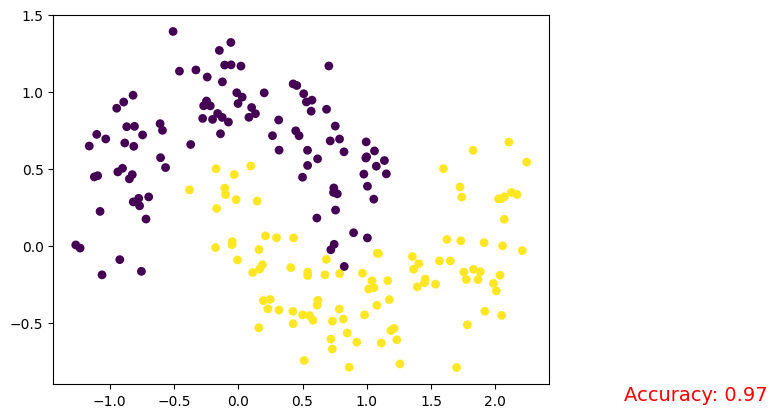

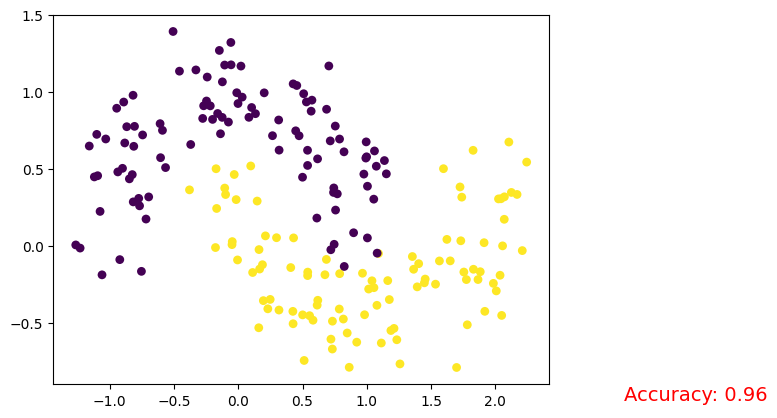

In [15]:
plt.ion()
for epoch in range(10000):
    out = network(x)
    loss = loss_function(out, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        max_value, prediction = torch.max(out, 1)
        predicted_y = prediction.data.numpy()
        target_y = y.data.numpy()
        plt.scatter(x.data.numpy()[:,0], x.data.numpy()[:,1], s=40, c=predicted_y, lw = 0)
        accuracy = (predicted_y == target_y).sum() / target_y.size
        plt.text(3, -1, 'Accuracy: %.2f' % accuracy, fontdict={'size': 14, 'color':  'red'})
        plt.pause(0.1)

plt.ioff()
plt.show()